# MiniBreakout Speedrun — DQN vs PPO vs GRPO

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/scan33scan33/coding-interview/blob/master/atari-speedrun/atari_speedrun.ipynb)

Train a network to **complete a tiny Atari-style game as fast as possible**, and
judge it by its completion time. We solve the same game three ways:

| algorithm | family | baseline for the advantage |
|-----------|--------|----------------------------|
| **DQN**  | value-based, off-policy | none — acts by `argmax Q`, learns from replay |
| **PPO**  | actor-critic, on-policy | a learned **value head** (GAE) |
| **GRPO** | policy-gradient, on-policy | the **mean of a group** of trajectories (no critic) |

DQN is the algorithm that first cleared Atari; PPO and GRPO are the ones used to
post-train LLMs. Everything runs on CPU in a couple of minutes with no ROM, no
gym, no ALE.

**This notebook is fully self-contained** — every class and function is defined
in the cells below, so it runs top-to-bottom on Colab (or anywhere) with only
`numpy`, `torch`, and `matplotlib`, all preinstalled on Colab. Nothing to clone.

In [1]:
# Colab already has these. Uncomment if you run somewhere that doesn't:
# !pip install torch numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt
import torch
print("torch", torch.__version__, "| numpy", np.__version__)

torch 2.13.0+cu130 | numpy 2.4.6


## The game (`MiniBreakout`)

A 5×5 grid Breakout. Bounce the ball off the paddle to chip away a wall of bricks;
the game is **completed** when the wall is cleared. Two rules make *speed* the
objective:

- **Any top-row contact chips one brick** ("chip the wall"), so the board is
  always clearable. (A literal grid Breakout is unwinnable: a pure-diagonal ball
  only ever visits one color of the checkerboard, so half the bricks are
  unreachable.)
- **A miss is fatal.** Winning therefore requires a whole *chain* of catches —
  the survival skill a random policy lacks.

In [2]:
"""MiniBreakout: a self-contained, dependency-free Atari-style game where the
agent is judged by HOW FAST it completes the game (a "speedrun").

Breakout is the canonical Atari RL benchmark. This is a shrunk, grid-based
version: bounce the ball off the paddle to chip away a wall of bricks. The
game is "completed" when the wall is cleared. No ROM / gym / ALE dependency,
and it trains a DQN on CPU in a couple of minutes.

Design choices that make SPEED the learnable objective:

  * Any ball contact with the top row removes one brick from the wall
    ("chip the wall"), so the board is always clearable — unlike literal
    Breakout, where a pure-diagonal grid ball can only reach one color of
    the checkerboard and half the bricks are unreachable.
  * A MISS (ball falls past the paddle) is NOT fatal: the ball respawns and
    the run continues, but the wasted round-trip costs time (and a penalty).
    So the only way to finish quickly is to stop missing — survival skill
    translates directly into completion speed.
  * A per-step time cost makes every wasted step hurt the return.

Metric: steps-to-complete (lower is better), plus completion rate within a
step budget. A random policy misses constantly and finishes slowly or times
out; a trained policy tracks the ball and speedruns the wall.

Coordinates: x in [0, W), y in [0, H); row 0 top (bricks), row H-1 paddle.
"""

import numpy as np

W, H = 5, 5          # screen size
PADDLE_W = 2         # paddle spans PADDLE_W columns
N_BRICKS = 6         # wall size (bricks to clear to win)
MAX_STEPS = 100

LEFT, STAY, RIGHT = 0, 1, 2
N_ACTIONS = 3

BRICK_REWARD = 1.0
WIN_BONUS = 5.0
MISS_PENALTY = -1.0
TIME_COST = 0.05

OBS_DIM = 6          # bx, by, vx, vy, px, bricks_left (all normalized)


class MiniBreakout:
    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        self.bricks_left = N_BRICKS
        self.px = (W - PADDLE_W) // 2
        self._launch()
        self.steps = 0
        self.done = False
        return self._obs()

    def snapshot(self):
        """Capture full episode state. GRPO samples a GROUP of trajectories
        from one identical starting state — snapshot/restore make that
        replay exact (dynamics are deterministic given actions; the only
        randomness is the launch at reset)."""
        return (self.bx, self.by, self.vx, self.vy, self.px,
                self.bricks_left, self.steps, self.done)

    def restore(self, snap):
        (self.bx, self.by, self.vx, self.vy, self.px,
         self.bricks_left, self.steps, self.done) = snap
        return self._obs()

    def _launch(self):
        """(Re)spawn the ball just above the paddle, heading up at an angle."""
        self.bx = int(self.rng.integers(0, W))
        self.by = H - 2
        self.vx = int(self.rng.choice([-1, 1]))
        self.vy = -1

    def _obs(self):
        return np.array([self.bx / (W - 1), self.by / (H - 1),
                         (self.vx + 1) / 2, (self.vy + 1) / 2,
                         self.px / (W - PADDLE_W),
                         self.bricks_left / N_BRICKS], dtype=np.float32)

    def _paddle_cols(self):
        return range(self.px, self.px + PADDLE_W)

    def step(self, action):
        assert not self.done, "step() called on a finished episode"
        self.steps += 1

        if action == LEFT:
            self.px = max(0, self.px - 1)
        elif action == RIGHT:
            self.px = min(W - PADDLE_W, self.px + 1)

        reward = -TIME_COST

        # Horizontal move with wall bounce.
        nx = self.bx + self.vx
        if nx < 0 or nx >= W:
            self.vx = -self.vx
            nx = self.bx + self.vx

        ny = self.by + self.vy
        if self.vy == -1 and ny <= 0:
            # Top row: chip one brick off the wall, bounce down.
            ny = 0
            if self.bricks_left > 0:
                self.bricks_left -= 1
                reward += BRICK_REWARD
            self.vy = 1
        elif self.vy == 1 and ny >= H - 1:
            if nx in self._paddle_cols():
                # Caught: bounce up with an angle set by the hit offset.
                offset = nx - self.px
                self.vx = -1 if offset < PADDLE_W / 2 else 1
                self.vy = -1
                ny = H - 1
            else:
                # Missed: game over. Winning therefore requires a whole chain
                # of successful catches, which is the survival skill the agent
                # must learn — and the reason a random policy rarely finishes.
                self.bx, self.by = nx, ny
                self.done = True
                return self._obs(), reward + MISS_PENALTY, True, self._info(won=False)

        self.bx, self.by = nx, ny

        if self.bricks_left == 0:
            self.done = True
            return self._obs(), reward + WIN_BONUS, True, self._info(won=True)

        if self.steps >= MAX_STEPS:
            self.done = True
            return self._obs(), reward, True, self._info(won=False)

        return self._obs(), reward, False, self._info(won=False)

    def _info(self, won):
        return {"won": won, "steps": self.steps, "bricks_left": self.bricks_left}

    def render(self):
        """ASCII 'pixel' frame, Atari-style, for eyeballing a rollout."""
        grid = [[" " for _ in range(W)] for _ in range(H)]
        for c in range(min(self.bricks_left, W)):     # remaining wall (top row)
            grid[0][c] = "="
        if 0 <= self.by < H:
            grid[self.by][self.bx] = "o"
        for c in self._paddle_cols():
            grid[H - 1][c] = "#"
        border = "+" + "-" * W + "+"
        return border + "\n" + "\n".join("|" + "".join(r) + "|" for r in grid) \
            + "\n" + border

In [3]:
game = MiniBreakout(seed=0)
game.reset()
print(game.render())
print("\nobservation (6 numbers, normalized):", np.round(game._obs(), 2))
print("[ball x, ball y, vx, vy, paddle x, bricks-left]")

+-----+
|=====|
|     |
|     |
|  o  |
| ##  |
+-----+

observation (6 numbers, normalized): [0.5  0.75 0.   0.   0.33 1.  ]
[ball x, ball y, vx, vy, paddle x, bricks-left]


### The metric: time-to-complete

Steps to clear the wall, with a **did-not-finish counted as the full step budget**
(`MAX_STEPS`). That is what makes "lower = faster" honest — a policy that dies at
step 12 scores 100, not 12. The physical floor is ~43 steps (6 bricks × one ball
round-trip each). A uniform-random policy almost never survives long enough:

In [4]:
def random_baseline(n=2000):
    e = MiniBreakout(seed=7); rng = np.random.default_rng(7)
    wins, times = 0, []
    for _ in range(n):
        e.reset(); done, info = False, {"won": False, "steps": 0}
        while not done:
            _, _, done, info = e.step(int(rng.integers(0, 3)))
        wins += info["won"]
        times.append(info["steps"] if info["won"] else MAX_STEPS)
    return wins / n, float(np.mean(times))

rand_completion, rand_time = random_baseline()
print(f"random policy: {rand_completion:.1%} completion, "
      f"{rand_time:.1f} mean steps-to-finish")

random policy: 4.2% completion, 97.6 mean steps-to-finish


## 1. DQN — value-based, off-policy

Textbook DQN (Mnih et al. 2015): a replay buffer, a target network, ε-greedy
exploration, and the Bellman target `y = r + γ·maxₐ' Q_target(s',a')` with
terminal transitions **not** bootstrapped (the `(1 − done)` mask).

In [5]:
"""DQN agent for MiniBreakout (Mnih et al. 2015, the algorithm that first
cleared Atari). Small enough to train on CPU in a couple of minutes.

The four ingredients that make DQN stable, each of which the tests probe:
  1. a replay buffer (decorrelate consecutive transitions),
  2. a target network (a periodically-frozen copy for bootstrap targets),
  3. epsilon-greedy exploration with decay,
  4. the Bellman target  y = r + gamma * max_a' Q_target(s', a')  with the
     terminal transition NOT bootstrapped (y = r when done).
"""

import random
from collections import deque

import numpy as np
import torch
import torch.nn.functional as F
from torch import nn



class QNet(nn.Module):
    def __init__(self, obs_dim=OBS_DIM, n_actions=N_ACTIONS, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions))

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity=20000):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, s2, done):
        self.buf.append((s, a, r, s2, float(done)))

    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        s, a, r, s2, d = zip(*batch)
        return (torch.tensor(np.array(s), dtype=torch.float32),
                torch.tensor(a, dtype=torch.int64),
                torch.tensor(r, dtype=torch.float32),
                torch.tensor(np.array(s2), dtype=torch.float32),
                torch.tensor(d, dtype=torch.float32))

    def __len__(self):
        return len(self.buf)


def td_loss(q, target_q, s, a, r, s2, done, gamma=0.99):
    """Bellman error. The `(1 - done)` mask is load-bearing: a terminal
    state has no future, so its target is just the reward — bootstrapping
    past a win/miss teaches the agent a value that doesn't exist."""
    q_sa = q(s).gather(1, a.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        next_q = target_q(s2).max(dim=1).values
        target = r + gamma * next_q * (1 - done)
    return F.smooth_l1_loss(q_sa, target)


@torch.no_grad()
def select_action(q, obs, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(0, N_ACTIONS))
    obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
    return int(q(obs_t).argmax(dim=1))

The training + greedy-evaluation harness (time-to-complete metric):

In [6]:
"""Training + evaluation harness: train a DQN to speedrun MiniBreakout and
watch the completion time drop.

The headline eval is TIME-TO-COMPLETE: steps taken to clear the wall, with a
did-not-finish (miss or timeout) counted as the full step budget. A random
policy almost never finishes, so its expected completion time is ~the cap;
a trained policy speedruns the wall in near-optimal steps.
"""

import copy

import numpy as np
import torch



@torch.no_grad()
def evaluate(q, n_episodes=500, seed=999):
    """Greedy rollouts. Returns (completion_rate, mean_time, mean_time_on_win).

    mean_time counts a DNF as MAX_STEPS — this is the "how fast do you
    complete the game" number (lower is better)."""
    env = MiniBreakout(seed=seed)
    rng = np.random.default_rng(seed)
    wins, times, win_times = 0, [], []
    for _ in range(n_episodes):
        obs = env.reset()
        done = False
        info = {"won": False, "steps": 0}
        while not done:
            a = select_action(q, obs, epsilon=0.0, rng=rng)
            obs, _, done, info = env.step(a)
        if info["won"]:
            wins += 1
            win_times.append(info["steps"])
            times.append(info["steps"])
        else:
            times.append(MAX_STEPS)          # DNF penalty = full budget
    return (wins / n_episodes, float(np.mean(times)),
            float(np.mean(win_times)) if win_times else float("nan"))


def train(steps=40000, batch_size=128, lr=1e-3, gamma=0.99,
          eps_start=1.0, eps_end=0.05, eps_decay_steps=15000,
          target_sync=500, warmup=1000, eval_every=5000, seed=0, log=True):
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    q = QNet()
    target_q = copy.deepcopy(q)
    opt = torch.optim.Adam(q.parameters(), lr=lr)
    buffer = ReplayBuffer()
    env = MiniBreakout(seed=seed)

    obs = env.reset()
    history = []
    c0, t0, w0 = evaluate(q)
    history.append({"step": 0, "completion": c0, "mean_time": t0, "win_time": w0})
    if log:
        print(f"step {0:>6}  completion {c0:5.1%}  mean_time {t0:5.1f}")

    for step in range(1, steps + 1):
        eps = max(eps_end, eps_start - (eps_start - eps_end) * step / eps_decay_steps)
        a = select_action(q, obs, eps, rng)
        obs2, r, done, _ = env.step(a)
        buffer.push(obs, a, r, obs2, done)
        obs = env.reset() if done else obs2

        if len(buffer) >= warmup:
            batch = buffer.sample(batch_size)
            loss = td_loss(q, target_q, *batch, gamma=gamma)
            opt.zero_grad()
            loss.backward()
            opt.step()
            if step % target_sync == 0:
                target_q.load_state_dict(q.state_dict())

        if step % eval_every == 0:
            c, t, w = evaluate(q)
            history.append({"step": step, "completion": c,
                            "mean_time": t, "win_time": w})
            if log:
                print(f"step {step:>6}  completion {c:5.1%}  "
                      f"mean_time {t:5.1f}  speedrun {w:5.1f}  eps {eps:.2f}")
    return q, history

# friendly aliases for this notebook
train_dqn, evaluate_dqn = train, evaluate

In [7]:
dqn_net, dqn_hist = train_dqn(steps=10000, eval_every=1000, seed=0, log=False)
c, t, w = evaluate_dqn(dqn_net, n_episodes=1000)
print(f"DQN final: {c:.1%} completion, {t:.1f} mean time, {w:.1f}-step speedrun")

DQN final: 100.0% completion, 43.0 mean time, 43.0-step speedrun


## 2 & 3. PPO and GRPO — policy gradient

Same game, two policy-gradient agents that differ only in **where the advantage
baseline comes from**:

- **PPO** — advantages from **GAE** against a learned **value head**, clipped
  surrogate over a few epochs per rollout.
- **GRPO** — *no critic*: sample a **group** of trajectories from one identical
  start state and standardize their returns within the group as the advantage
  (the LLM GRPO recipe, with "prompt" = initial game state; `snapshot`/`restore`
  keep the group's start state identical so only the actions vary).

In [8]:
"""Policy-gradient agents for MiniBreakout: PPO and GRPO.

Same game, same completion-time metric as the DQN (dqn.py) — the point is to
contrast three algorithm families on identical footing:

  DQN  (dqn.py)  value-based, off-policy, replay buffer, Bellman targets
  PPO  (here)    actor-critic, on-policy, GAE advantages, clipped surrogate
  GRPO (here)    critic-free, on-policy, GROUP-relative trajectory advantages

PPO and GRPO share the actor, the clipped surrogate, and the entropy bonus;
they differ only in where the advantage comes from — a learned value baseline
(PPO/GAE) vs standardizing returns within a group of trajectories sampled from
the same start state (GRPO). That is exactly the LLM GRPO idea (a group of
completions per prompt), with "prompt" = initial game state.
"""

import copy

import numpy as np
import torch
import torch.nn.functional as F
from torch import nn



class ActorCritic(nn.Module):
    def __init__(self, obs_dim=OBS_DIM, n_actions=N_ACTIONS, hidden=64):
        super().__init__()
        self.trunk = nn.Sequential(nn.Linear(obs_dim, hidden), nn.Tanh(),
                                   nn.Linear(hidden, hidden), nn.Tanh())
        self.actor = nn.Linear(hidden, n_actions)
        self.critic = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.trunk(x)
        return self.actor(h), self.critic(h).squeeze(-1)

    def logits(self, x):
        return self.actor(self.trunk(x))


# ---------- greedy evaluation (shared metric with the DQN) ----------

@torch.no_grad()
def evaluate_policy(policy, n_episodes=500, seed=999):
    """Greedy (argmax) rollouts. Returns (completion_rate, mean_time,
    mean_time_on_win); mean_time counts a DNF as MAX_STEPS."""
    env = MiniBreakout(seed=seed)
    wins, times, win_times = 0, [], []
    for _ in range(n_episodes):
        obs = env.reset()
        done, info = False, {"won": False, "steps": 0}
        while not done:
            a = int(policy.logits(torch.tensor(obs).unsqueeze(0)).argmax())
            obs, _, done, info = env.step(a)
        if info["won"]:
            wins += 1
            win_times.append(info["steps"])
            times.append(info["steps"])
        else:
            times.append(MAX_STEPS)
    return (wins / n_episodes, float(np.mean(times)),
            float(np.mean(win_times)) if win_times else float("nan"))


# ---------- shared math ----------

def gae(rewards, values, dones, gamma=0.99, lam=0.95):
    """Generalized Advantage Estimation. `dones[t]` marks the last step of an
    episode, where the bootstrap is cut (no future beyond a terminal state)."""
    adv = np.zeros(len(rewards), dtype=np.float32)
    last = 0.0
    for t in reversed(range(len(rewards))):
        nonterminal = 1.0 - dones[t]
        next_v = values[t + 1] if t + 1 < len(values) else 0.0
        delta = rewards[t] + gamma * next_v * nonterminal - values[t]
        last = delta + gamma * lam * nonterminal * last
        adv[t] = last
    return adv


def clipped_surrogate(new_logp, old_logp, adv, clip_eps=0.2):
    ratio = (new_logp - old_logp).exp()
    return -torch.minimum(ratio * adv,
                          ratio.clamp(1 - clip_eps, 1 + clip_eps) * adv).mean()


def group_advantages(returns, eps=1e-4):
    """GRPO's baseline: standardize trajectory returns WITHIN a group sampled
    from the same start state. No critic — the group mean IS the baseline."""
    returns = np.asarray(returns, dtype=np.float32)
    return (returns - returns.mean()) / (returns.std() + eps)


# ---------- PPO ----------

def collect_rollout(policy, env, obs, n_steps, rng):
    """Run the current policy for n_steps, splitting across episodes.
    Returns arrays plus the value at the final (possibly mid-episode) state."""
    O, A, R, D, LP, V = [], [], [], [], [], []
    for _ in range(n_steps):
        obs_t = torch.tensor(obs).unsqueeze(0)
        with torch.no_grad():
            logits, value = policy(obs_t)
        dist = torch.distributions.Categorical(logits=logits)
        a = dist.sample()
        O.append(obs); A.append(int(a)); LP.append(float(dist.log_prob(a)))
        V.append(float(value))
        obs, r, done, _ = env.step(int(a))
        R.append(r); D.append(float(done))
        obs = env.reset() if done else obs
    with torch.no_grad():
        _, last_v = policy(torch.tensor(obs).unsqueeze(0))
    return (np.array(O, np.float32), np.array(A), np.array(R, np.float32),
            np.array(D, np.float32), np.array(LP, np.float32),
            np.array(V + [float(last_v)], np.float32), obs)


def train_ppo(iters=300, n_steps=512, epochs=4, minibatch=128, lr=3e-3,
              gamma=0.99, lam=0.95, clip_eps=0.2, ent_coef=0.01,
              value_coef=0.5, eval_every=30, seed=0, log=True):
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    policy = ActorCritic()
    opt = torch.optim.Adam(policy.parameters(), lr=lr)
    env = MiniBreakout(seed=seed)
    obs = env.reset()

    history = []
    c0, t0, w0 = evaluate_policy(policy)
    history.append({"step": 0, "completion": c0, "mean_time": t0, "win_time": w0})
    if log:
        print(f"iter {0:>4}  completion {c0:5.1%}  mean_time {t0:5.1f}")

    for it in range(1, iters + 1):
        O, A, R, D, LP, Vplus, obs = collect_rollout(policy, env, obs, n_steps, rng)
        adv = gae(R, Vplus, D, gamma, lam)
        ret = adv + Vplus[:-1]
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        O_t = torch.tensor(O); A_t = torch.tensor(A)
        LP_t = torch.tensor(LP); adv_t = torch.tensor(adv); ret_t = torch.tensor(ret)

        idx = np.arange(n_steps)
        for _ in range(epochs):
            rng.shuffle(idx)
            for s in range(0, n_steps, minibatch):
                b = idx[s:s + minibatch]
                logits, value = policy(O_t[b])
                dist = torch.distributions.Categorical(logits=logits)
                new_lp = dist.log_prob(A_t[b])
                pg = clipped_surrogate(new_lp, LP_t[b], adv_t[b], clip_eps)
                vloss = F.mse_loss(value, ret_t[b])
                loss = pg + value_coef * vloss - ent_coef * dist.entropy().mean()
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(policy.parameters(), 0.5)
                opt.step()

        if it % eval_every == 0:
            c, t, w = evaluate_policy(policy)
            history.append({"step": it, "completion": c, "mean_time": t, "win_time": w})
            if log:
                print(f"iter {it:>4}  completion {c:5.1%}  mean_time {t:5.1f}  "
                      f"speedrun {w:5.1f}")
    return policy, history


# ---------- GRPO ----------

def sample_trajectory(policy, env, init_state, max_len, rng):
    """One trajectory from a FIXED initial state (restore snapshot)."""
    obs = env.restore(init_state)
    O, A, LP, total_r = [], [], [], 0.0
    done = False
    for _ in range(max_len):
        with torch.no_grad():
            dist = torch.distributions.Categorical(
                logits=policy.logits(torch.tensor(obs).unsqueeze(0)))
        a = dist.sample()
        O.append(obs); A.append(int(a)); LP.append(float(dist.log_prob(a)))
        obs, r, done, _ = env.step(int(a))
        total_r += r
        if done:
            break
    return O, A, LP, total_r


def train_grpo(iters=300, prompts_per_iter=8, group_size=8, epochs=4,
               minibatch=256, lr=2e-3, clip_eps=0.2, ent_coef=0.004,
               eval_every=30, seed=0, log=True):
    """Critic-free: for each start state, sample `group_size` trajectories,
    standardize their TOTAL returns within the group -> one advantage per
    trajectory, broadcast to all its timesteps. No value network, no GAE."""
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    policy = ActorCritic()          # critic head unused; reused for a fair net
    opt = torch.optim.Adam(policy.parameters(), lr=lr)
    env = MiniBreakout(seed=seed)

    history = []
    c0, t0, w0 = evaluate_policy(policy)
    history.append({"step": 0, "completion": c0, "mean_time": t0, "win_time": w0})
    if log:
        print(f"iter {0:>4}  completion {c0:5.1%}  mean_time {t0:5.1f}")

    for it in range(1, iters + 1):
        O, A, LP, ADV = [], [], [], []
        for _ in range(prompts_per_iter):
            env.reset()
            init_state = env.snapshot()
            returns, trajs = [], []
            for _ in range(group_size):
                o, a, lp, tot = sample_trajectory(policy, env, init_state,
                                                  MAX_STEPS, rng)
                trajs.append((o, a, lp)); returns.append(tot)
            # Group-relative advantage: standardize returns WITHIN the group.
            adv = group_advantages(returns)
            for (o, a, lp), ad in zip(trajs, adv):
                O.extend(o); A.extend(a); LP.extend(lp); ADV.extend([ad] * len(o))

        O_t = torch.tensor(np.array(O, np.float32)); A_t = torch.tensor(A)
        LP_t = torch.tensor(np.array(LP, np.float32))
        ADV_t = torch.tensor(np.array(ADV, np.float32))

        idx = np.arange(len(O))
        for _ in range(epochs):
            rng.shuffle(idx)
            for s in range(0, len(O), minibatch):
                b = idx[s:s + minibatch]
                dist = torch.distributions.Categorical(logits=policy.logits(O_t[b]))
                new_lp = dist.log_prob(A_t[b])
                pg = clipped_surrogate(new_lp, LP_t[b], ADV_t[b], clip_eps)
                loss = pg - ent_coef * dist.entropy().mean()
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(policy.parameters(), 0.5)
                opt.step()

        if it % eval_every == 0:
            c, t, w = evaluate_policy(policy)
            history.append({"step": it, "completion": c, "mean_time": t, "win_time": w})
            if log:
                print(f"iter {it:>4}  completion {c:5.1%}  mean_time {t:5.1f}  "
                      f"speedrun {w:5.1f}")
    return policy, history

In [9]:
ppo_net, ppo_hist = train_ppo(iters=50, eval_every=5, seed=0, log=False)
c, t, w = evaluate_policy(ppo_net, n_episodes=1000)
print(f"PPO final: {c:.1%} completion, {t:.1f} mean time, {w:.1f}-step speedrun")

PPO final: 100.0% completion, 43.0 mean time, 43.0-step speedrun


In [10]:
grpo_net, grpo_hist = train_grpo(iters=50, eval_every=5, seed=0, log=False)
c, t, w = evaluate_policy(grpo_net, n_episodes=1000)
print(f"GRPO final: {c:.1%} completion, {t:.1f} mean time, {w:.1f}-step speedrun")

GRPO final: 100.0% completion, 43.0 mean time, 43.0-step speedrun


## Results

All three reach the physical speed limit. The x-axis below is *normalized training
progress* because the methods count training in different units (DQN gradient
steps vs PPO/GRPO rollout iterations).

In [11]:
runs = {"DQN": dqn_hist, "PPO": ppo_hist, "GRPO": grpo_hist}
print(f"{'algorithm':<14}{'completion':>12}{'time-to-finish':>16}{'speedrun':>10}")
print("-" * 52)
print(f"{'random':<14}{rand_completion:>11.1%}{rand_time:>16.1f}{'--':>10}")
for name, h in runs.items():
    f = h[-1]
    print(f"{name:<14}{f['completion']:>11.1%}{f['mean_time']:>16.1f}"
          f"{f['win_time']:>10.1f}")

algorithm       completion  time-to-finish  speedrun
----------------------------------------------------
random               4.2%            97.6        --
DQN                100.0%            43.0      43.0
PPO                100.0%            43.0      43.0
GRPO               100.0%            43.0      43.0


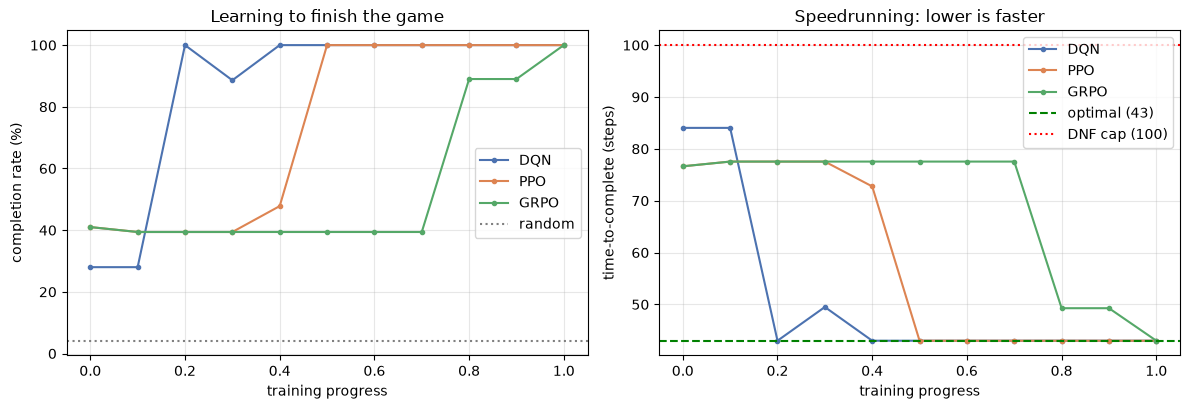

In [12]:
def progress(h):
    last = h[-1]["step"] or 1
    return [x["step"] / last for x in h]

colors = {"DQN": "#4C72B0", "PPO": "#DD8452", "GRPO": "#55A868"}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

for name, h in runs.items():
    ax1.plot(progress(h), [x["completion"] * 100 for x in h],
             marker="o", ms=3, color=colors[name], label=name)
ax1.axhline(rand_completion * 100, ls=":", c="gray", label="random")
ax1.set_xlabel("training progress"); ax1.set_ylabel("completion rate (%)")
ax1.set_title("Learning to finish the game"); ax1.legend(); ax1.grid(alpha=.3)

for name, h in runs.items():
    ax2.plot(progress(h), [x["mean_time"] for x in h],
             marker="o", ms=3, color=colors[name], label=name)
ax2.axhline(43, ls="--", c="green", label="optimal (43)")
ax2.axhline(MAX_STEPS, ls=":", c="red", label="DNF cap (100)")
ax2.set_xlabel("training progress"); ax2.set_ylabel("time-to-complete (steps)")
ax2.set_title("Speedrunning: lower is faster"); ax2.legend(); ax2.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Watch a trained agent speedrun

Greedy rollout from the trained PPO policy — the wall depletes as the ball is
kept alive and bounced into the top row.

In [13]:
def render_frames(policy, seed=123):
    e = MiniBreakout(seed=seed); obs = e.reset(); frames = [e.render()]
    done, info = False, {"won": False}
    while not done:
        a = int(policy.logits(torch.tensor(obs).unsqueeze(0)).argmax())
        obs, _, done, info = e.step(a); frames.append(e.render())
    return frames, info

frames, info = render_frames(ppo_net)
print(f"result: {'WON' if info['won'] else 'DNF'} in {info['steps']} steps\n")
for label, fr in [("start", frames[0]), ("mid", frames[len(frames)//2]),
                  ("end", frames[-1])]:
    print(f"--- {label} ---"); print(fr)

result: WON in 43 steps

--- start ---
+-----+
|=====|
|     |
|     |
|  o  |
| ##  |
+-----+
--- mid ---
+-----+
|===  |
|     |
|     |
|    o|
|   ##|
+-----+
--- end ---
+-----+
| o   |
|     |
|     |
|     |
|##   |
+-----+


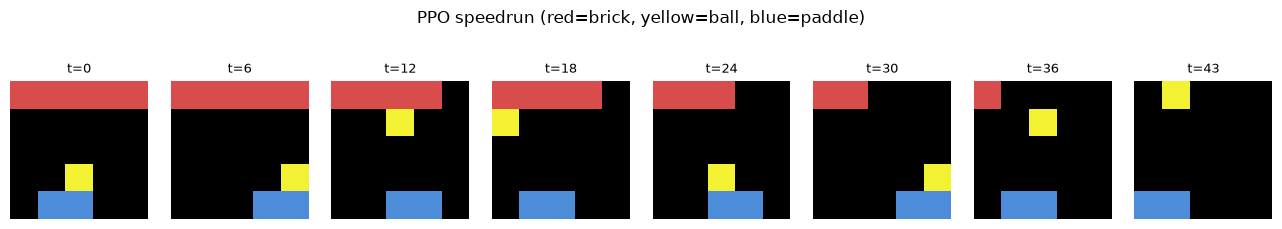

In [14]:
def to_image(frame_str):
    rows = [r[1:-1] for r in frame_str.splitlines()[1:-1]]  # strip borders
    img = np.zeros((len(rows), len(rows[0]), 3))
    for y, row in enumerate(rows):
        for x, ch in enumerate(row):
            if ch == "=": img[y, x] = [0.85, 0.30, 0.30]    # brick
            elif ch == "o": img[y, x] = [0.95, 0.95, 0.20]  # ball
            elif ch == "#": img[y, x] = [0.30, 0.55, 0.85]  # paddle
    return img

picks = np.linspace(0, len(frames) - 1, 8).astype(int)
fig, axes = plt.subplots(1, len(picks), figsize=(13, 2))
for ax, i in zip(axes, picks):
    ax.imshow(to_image(frames[i]), interpolation="nearest")
    ax.set_title(f"t={i}", fontsize=9); ax.axis("off")
plt.suptitle("PPO speedrun (red=brick, yellow=ball, blue=paddle)", y=1.12)
plt.tight_layout(); plt.show()

## Takeaways

- **All three algorithms reach the ~43-step speed limit** from a ~4% random
  baseline — the game is small, so the interesting part is *how* each defines its
  advantage, not the final score.
- **DQN** is sample-efficient (it replays every transition many times) but needs
  the target-network machinery to stay stable.
- **PPO** trains a critic as its baseline; **GRPO** throws the critic away and
  uses a group mean instead — cheaper by design, but it pays by sampling a whole
  group per start state and can wobble once the group collapses to identical
  trajectories (zero-variance advantage).
- The same `(1 − done)` terminal-bootstrap discipline shows up in **both** DQN's
  Bellman target and PPO's GAE — forget it in either place and the agent chases
  the value of a future that isn't reachable.

The same code lives as reference modules (`env.py`, `dqn.py`, `train.py`,
`pg.py`) with a `README.md` of gotchas and interview follow-ups in the
[`atari-speedrun`](https://github.com/scan33scan33/coding-interview/tree/master/atari-speedrun)
folder.